# Step 1: Environment Setup

## Objective
Recreate the software environment used during fine-tuning and inference to ensure compatibility with the Qwen2.5-VL model and LoRA adapter.

## What this step does
- Installs pinned package versions.
- Avoids compatibility issues introduced by newer Transformers releases.
- Prepares the notebook for loading the processor and model.

## Expected Output
- Installation completes without errors.
- The notebook is ready for a kernel restart.

In [1]:
# Install Compatible Versions
!pip uninstall -y transformers peft accelerate trl bitsandbytes -q

!pip install -q \
transformers==4.53.3 \
peft==0.17.0 \
accelerate==1.8.1 \
trl==0.19.1 \
bitsandbytes==0.46.1 \
sentencepiece \
einops \
safetensors

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 98.6 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.9/503.9 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.3/365.3 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.2/376.2 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 23.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 94.9 MB/s eta 0:00:00


In [2]:
!pip install -q qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 52.2 MB/s eta 0:00:00:00:0100:01


In [3]:
import torch
import transformers
import peft
import accelerate
import trl

print("PyTorch      :", torch.__version__)
print("Transformers :", transformers.__version__)
print("PEFT         :", peft.__version__)
print("Accelerate   :", accelerate.__version__)
print("TRL          :", trl.__version__)
print("CUDA         :", torch.cuda.is_available())
print("GPU          :", torch.cuda.get_device_name(0))

PyTorch      : 2.10.0+cu128
Transformers : 4.53.3
PEFT         : 0.17.0
Accelerate   : 1.8.1
TRL          : 0.19.1
CUDA         : True
GPU          : Tesla T4


# Step 2: Define Project Paths

## Objective
Define all dataset and model paths in one place.

## What this step does
- Sets paths for the LoRA adapter, dataset, selected samples, and test images.
- Verifies that all required files exist.

## Expected Output
All required paths are found successfully.

In [4]:
# Project Paths
import os

ROOT = "/kaggle/input/datasets/bbeastboy/explainability-assets/explainability_assets"

MODEL_DIR = os.path.join(ROOT, "qwen2.5vl_lora")
ADAPTER_DIR = os.path.join(MODEL_DIR, "adapter")

DATASET_DIR = os.path.join(ROOT, "dataset")
INFERENCE_DIR = os.path.join(ROOT, "inference")

TEST_DIR = os.path.join(ROOT, "test_images")
SELECTED_SAMPLES = os.path.join(TEST_DIR, "selected_samples.csv")

# Verify Paths
required_paths = {
    "Model Folder": MODEL_DIR,
    "Adapter": ADAPTER_DIR,
    "Dataset": DATASET_DIR,
    "Inference": INFERENCE_DIR,
    "Test Images": TEST_DIR,
    "Selected Samples": SELECTED_SAMPLES,
}

print("=" * 60)
print("Path Verification")
print("=" * 60)

for name, path in required_paths.items():
    print(f"{'✓' if os.path.exists(path) else '✗'} {name:<20}: {path}")

print("=" * 60)

Path Verification
✓ Model Folder        : /kaggle/input/datasets/bbeastboy/explainability-assets/explainability_assets/qwen2.5vl_lora
✓ Adapter             : /kaggle/input/datasets/bbeastboy/explainability-assets/explainability_assets/qwen2.5vl_lora/adapter
✓ Dataset             : /kaggle/input/datasets/bbeastboy/explainability-assets/explainability_assets/dataset
✓ Inference           : /kaggle/input/datasets/bbeastboy/explainability-assets/explainability_assets/inference
✓ Test Images         : /kaggle/input/datasets/bbeastboy/explainability-assets/explainability_assets/test_images
✓ Selected Samples    : /kaggle/input/datasets/bbeastboy/explainability-assets/explainability_assets/test_images/selected_samples.csv


# Step 3: Load the Processor

## Objective
Load the same processor used during fine-tuning and inference.

## What this step does
- Downloads the official Qwen2.5-VL processor.
- Configures the same image resolution used during training.
- Verifies successful initialization.

## Expected Output
- Processor loads successfully.
- Processor type is `Qwen2_5_VLProcessor`.

In [5]:
# Load Processor
from transformers import AutoProcessor

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"

print("=" * 60)
print("Loading Processor")
print("=" * 60)

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    min_pixels=224*28*28,
    max_pixels=196*28*28,   # reduced from 384
)

print("✓ Processor Loaded Successfully")
print("=" * 60)

print(type(processor))

Loading Processor


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


chat_template.json: 0.00B [00:00, ?B/s]

✓ Processor Loaded Successfully
<class 'transformers.models.qwen2_5_vl.processing_qwen2_5_vl.Qwen2_5_VLProcessor'>


# Step 4: Load the Fine-Tuned Model

## Objective
Load the original Qwen2.5-VL-3B model and attach the fine-tuned LoRA adapter.

## What this step does
- Loads the base model.
- Loads your best LoRA adapter.
- Merges them into a single inference model.
- Switches the model to evaluation mode.

## Expected Output
- Base model loaded.
- LoRA adapter loaded.
- Model ready for inference and explainability.

In [6]:
# Load Base Model
from transformers import Qwen2_5_VLForConditionalGeneration
from peft import PeftModel

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"

print("=" * 60)
print("Loading Base Model")
print("=" * 60)

base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)

print("✓ Base Model Loaded")

# Attach LoRA Adapter
print("\nLoading LoRA Adapter...")

model = PeftModel.from_pretrained(
    base_model,
    ADAPTER_DIR,
)

model.eval()

print("✓ LoRA Adapter Loaded")
print("✓ Model Ready for Explainability")

print("=" * 60)

Loading Base Model


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.53G [00:00<?, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

✓ Base Model Loaded

Loading LoRA Adapter...


/usr/local/lib/python3.12/dist-packages/peft/config.py:165: UserWarning: Unexpected keyword arguments ['alora_invocation_tokens', 'arrow_config', 'ensure_weight_tying', 'lora_ga_config', 'peft_version', 'use_bdlora'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


✓ LoRA Adapter Loaded
✓ Model Ready for Explainability


# Step 5: Load Explainability Samples

## Objective
Load the curated explainability dataset that will be used throughout the notebook.

## What this step does
- Loads the selected samples CSV.
- Verifies the dataset structure.
- Displays the first few samples.

## Expected Output
- 35 samples loaded.
- Required columns verified.

In [7]:
# Load Selected Samples
import pandas as pd

samples = pd.read_csv(SELECTED_SAMPLES)

print("=" * 60)
print("Explainability Dataset")
print("=" * 60)

print(f"Total Samples : {len(samples)}")
print(f"Columns       : {list(samples.columns)}")

display(samples.head())

# Verify Required Columns
required_columns = [
    "image",
    "instrument",
    "question",
    "ground_truth",
    "prediction",
    "failure_category"
]

missing = [c for c in required_columns if c not in samples.columns]

if len(missing) == 0:
    print("\n✓ All required columns are present.")
else:
    print("\nMissing columns:", missing)

Explainability Dataset
Total Samples : 35
Columns       : ['image', 'instrument', 'question_id', 'concept', 'question', 'ground_truth', 'prediction', 'failure_category', 'predicted_attribute']


,image,instrument,question_id,concept,question,ground_truth,prediction,failure_category,predicted_attribute
0,bahi_test3.jpg,bahi,q3,material,What material is this instrument made of?,This instrument is made of bamboo.,This instrument is made of bamboo.,Correct,NaN
1,bahi_test5.jpg,bahi,q2,origin,Where did this instrument originate?,It originated in the rural communities of Assam.,This instrument is made from a single piece of...,Question Misunderstanding,material
2,bahi_test4.jpg,bahi,q9,description,Give a description of this instrument includin...,The Bahi is a traditional Assamese transverse ...,The Bahi is a transverse bamboo flute that is ...,Truncation,description
3,bahi_test2.jpg,bahi,q7,playing_method,How is this instrument played?,This instrument is played by blowing air acros...,This instrument is played by placing both mout...,Hallucination,playing_method
4,bahi_test1.jpg,bahi,q6,traditional_player,Which gender traditionally plays this instrument?,This instrument is traditionally played by men.,This instrument is traditionally played by men...,Repetition,traditional_player



✓ All required columns are present.


# Step 6: Build the Inference Pipeline

## Objective
Reproduce the exact inference pipeline used during evaluation.

## What this step does
- Loads one sample from the explainability dataset.
- Builds the Qwen2.5-VL conversation.
- Prepares image and text inputs.
- Generates a prediction.

## Expected Output
A decoded prediction from the fine-tuned model.

In [8]:
# Required Imports

import os
from PIL import Image

from qwen_vl_utils import process_vision_info

Selected Sample
Instrument : bahi
Question   : What material is this instrument made of?
Image      : /kaggle/input/datasets/bbeastboy/explainability-assets/explainability_assets/test_images/bahi/bahi_test3.jpg
Ground Truth:
This instrument is made of bamboo.


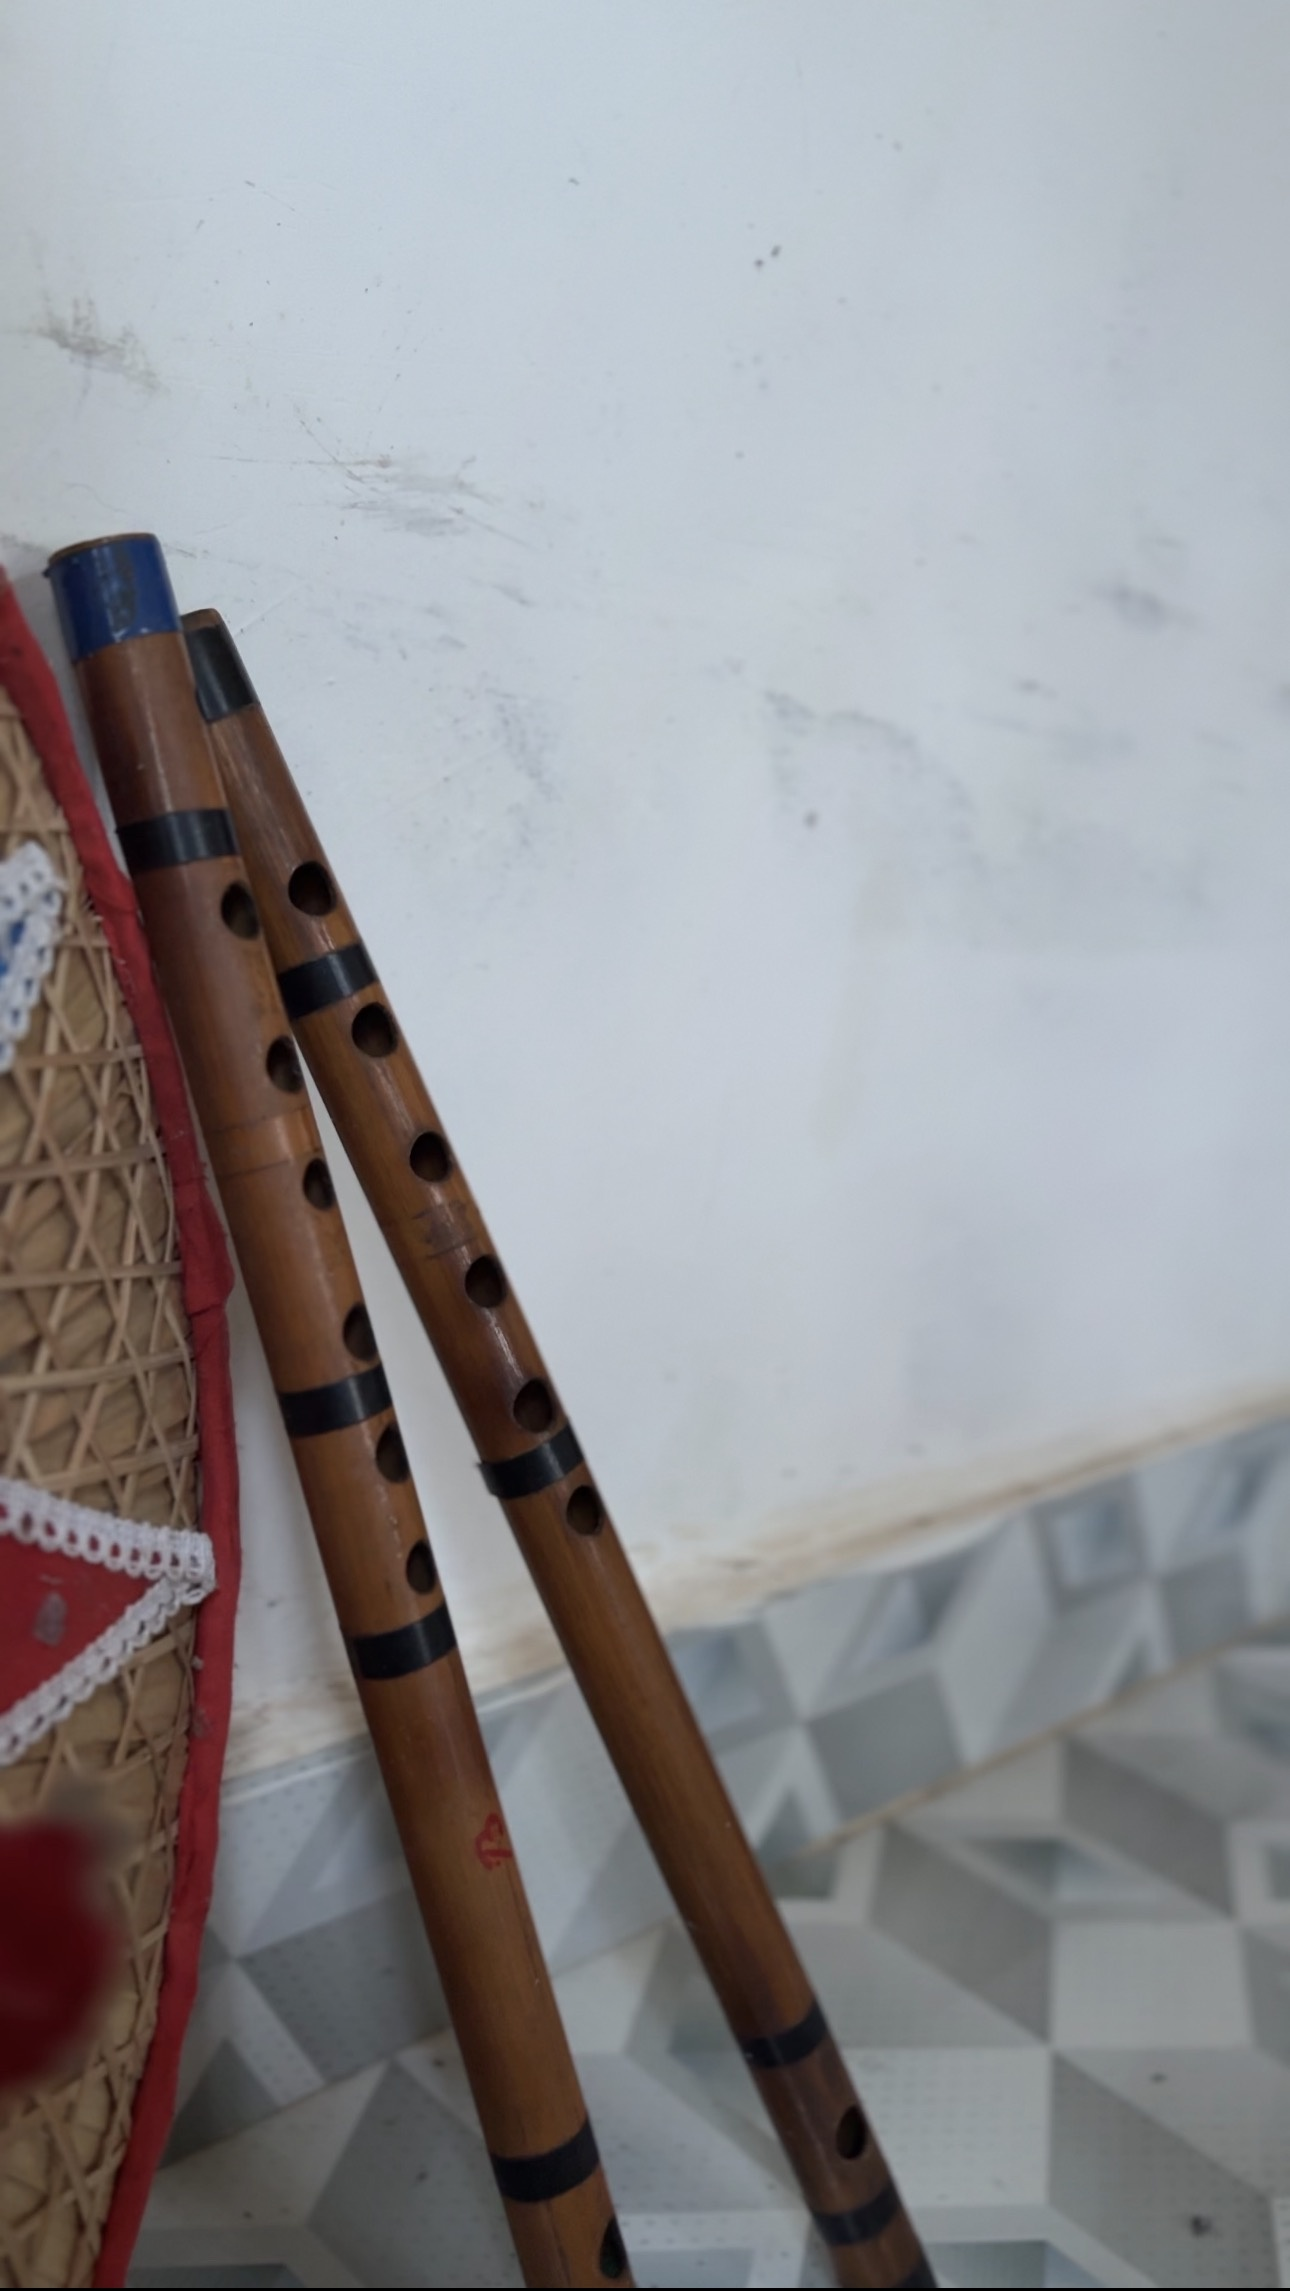

In [9]:
# Select One Sample
sample = samples.iloc[0]

image_path = os.path.join(
    TEST_DIR,
    sample["instrument"],
    sample["image"]
)

question = sample["question"]

print("=" * 60)
print("Selected Sample")
print("=" * 60)

print("Instrument :", sample["instrument"])
print("Question   :", question)
print("Image      :", image_path)
print("Ground Truth:")
print(sample["ground_truth"])

print("=" * 60)

Image.open(image_path)

In [12]:
# Build Conversation
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image_path,
            },
            {
                "type": "text",
                "text": question,
            },
        ],
    }
]

In [13]:
# Prepare Model Inputs
text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)

inputs = inputs.to(model.device)

print("✓ Inputs Prepared")

✓ Inputs Prepared


# Step 7: Reproduce Model Prediction

## Objective
Verify that the fine-tuned model reproduces the prediction for a selected sample before any explainability analysis.

## What this step does
- Generates the model response.
- Decodes the output.
- Compares it with the stored prediction.

## Expected Output
The generated prediction should closely match the stored prediction.

In [14]:
# Generate Prediction
with torch.no_grad():

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=64,
        do_sample=False,
    )

generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]

prediction = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0]

print("=" * 60)
print("QUESTION")
print("=" * 60)
print(question)

print("\n" + "=" * 60)
print("MODEL PREDICTION")
print("=" * 60)
print(prediction)

print("\n" + "=" * 60)
print("STORED PREDICTION")
print("=" * 60)
print(sample["prediction"])

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


QUESTION
What material is this instrument made of?

MODEL PREDICTION
This instrument is made of bamboo.

STORED PREDICTION
This instrument is made of bamboo.


# Step 8: Enable Attention Extraction

## Objective
Reload the fine-tuned model using the eager attention backend so that transformer attention matrices are returned.

## Why this is required
The default SDPA backend optimizes inference but does not expose attention weights. Attention-based explainability methods require explicit attention matrices.

## Expected Output
- Base model loaded with eager attention.
- LoRA adapter attached.
- Model ready for attention extraction.

In [15]:
# Reload Model with Eager Attention
import gc
import torch

# Free previous model
del model
del base_model

gc.collect()
torch.cuda.empty_cache()

print("=" * 60)
print("Reloading Model with Eager Attention")
print("=" * 60)

base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,          # T4 compatible
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="eager",        # <-- IMPORTANT
)

model = PeftModel.from_pretrained(
    base_model,
    ADAPTER_DIR,
)

model.eval()

print("✓ Model Loaded")

print("\nAttention Backend :", base_model.config._attn_implementation)

print("=" * 60)

Reloading Model with Eager Attention


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✓ Model Loaded

Attention Backend : eager


/usr/local/lib/python3.12/dist-packages/peft/config.py:165: UserWarning: Unexpected keyword arguments ['alora_invocation_tokens', 'arrow_config', 'ensure_weight_tying', 'lora_ga_config', 'peft_version', 'use_bdlora'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


In [16]:
# Forward Pass with Attention
with torch.no_grad():

    outputs = model(
        **inputs,
        output_attentions=True,
        return_dict=True,
    )

attentions = outputs.attentions

print("=" * 60)
print("Attention Extraction")
print("=" * 60)

print("Type               :", type(attentions))
print("Number of Layers   :", len(attentions))
print("Layer 0            :", type(attentions[0]))

if attentions[0] is not None:
    print("Layer 0 Shape      :", attentions[0].shape)
else:
    print("Layer 0 Shape      : None")

print("=" * 60)

Attention Extraction
Type               : <class 'tuple'>
Number of Layers   : 36
Layer 0            : <class 'torch.Tensor'>
Layer 0 Shape      : torch.Size([1, 16, 209, 209])


# Step 9: Inspect the Input Token Sequence

## Objective
Understand how the multimodal input is represented internally.

## What this step does
- Decodes every input token.
- Maps token IDs to readable tokens.
- Identifies the positions of image and text tokens.

## Expected Output
A table showing token index, token ID, and decoded token.

In [15]:
# Decode Input Tokens

input_ids = inputs["input_ids"][0]

tokens = processor.tokenizer.convert_ids_to_tokens(input_ids)

token_df = pd.DataFrame({
    "Index": range(len(tokens)),
    "Token ID": input_ids.cpu().tolist(),
    "Token": tokens,
})

print("=" * 60)
print(f"Total Tokens : {len(token_df)}")
print("=" * 60)

display(token_df.head(50))

Total Tokens : 393


,Index,Token ID,Token
0,0,151644,<|im_start|>
1,1,8948,system
2,2,198,Ċ
3,3,2610,You
4,4,525,Ġare
5,5,264,Ġa
6,6,10950,Ġhelpful
7,7,17847,Ġassistant
8,8,13,.
9,9,151645,<|im_end|>


# Step 9.1: Locate Special Tokens

## Objective
Identify the boundaries between image tokens and text tokens.

## Expected Output
Indices of:
- Vision Start
- Vision End
- Image Tokens
- Assistant Start

In [16]:
# Locate Important Special Tokens
special_tokens = {
    "<|vision_start|>": 151652,
    "<|vision_end|>": 151653,
    "<|image_pad|>": 151655,
    "<|im_start|>": 151644,
    "<|im_end|>": 151645,
}

input_ids_list = input_ids.cpu().tolist()

for name, token_id in special_tokens.items():
    positions = [i for i, x in enumerate(input_ids_list) if x == token_id]

    print("=" * 60)
    print(name)
    print(f"Occurrences : {len(positions)}")

    if len(positions):
        print("First 10 Positions:", positions[:10])

<|vision_start|>
Occurrences : 1
First 10 Positions: [14]
<|vision_end|>
Occurrences : 1
First 10 Positions: [379]
<|image_pad|>
Occurrences : 364
First 10 Positions: [15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
<|im_start|>
Occurrences : 3
First 10 Positions: [0, 11, 390]
<|im_end|>
Occurrences : 2
First 10 Positions: [9, 388]


# Step 10: Visualize Raw Attention

## Objective
Inspect the attention matrix from one transformer layer and one attention head.

## What this step does
- Selects one attention head.
- Displays its attention matrix as a heatmap.
- Provides the first direct view of how the model distributes attention across image and text tokens.

## Expected Output
A 393 × 393 attention heatmap.

In [8]:
# Visualize Raw Attention
import matplotlib.pyplot as plt

layer_idx = 0
head_idx = 0

attention = attentions[layer_idx][0, head_idx].cpu().float().numpy()

print("=" * 60)
print("Attention Matrix")
print("=" * 60)

print("Layer :", layer_idx)
print("Head  :", head_idx)
print("Shape :", attention.shape)

plt.figure(figsize=(10, 8))

plt.imshow(attention, aspect="auto")
plt.colorbar()

plt.title(f"Layer {layer_idx} | Head {head_idx}")

plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")

plt.tight_layout()
plt.show()

NameError: name 'attentions' is not defined

# Step 11: Average Attention Across Heads

## Objective

Combine the attention from all heads into a single attention matrix for one layer.

## Why?

Instead of analyzing 16 separate attention heads, we first compute their average.

This averaged attention matrix is the input to Attention Rollout.

## Expected Output

One 393 × 393 attention matrix.

In [18]:
# Average Attention Across Heads
layer_idx = 0

avg_attention = attentions[layer_idx][0].mean(dim=0)

print("=" * 60)
print("Average Attention")
print("=" * 60)

print("Shape :", avg_attention.shape)

avg_attention = avg_attention.cpu().numpy()

Average Attention
Shape : torch.Size([393, 393])


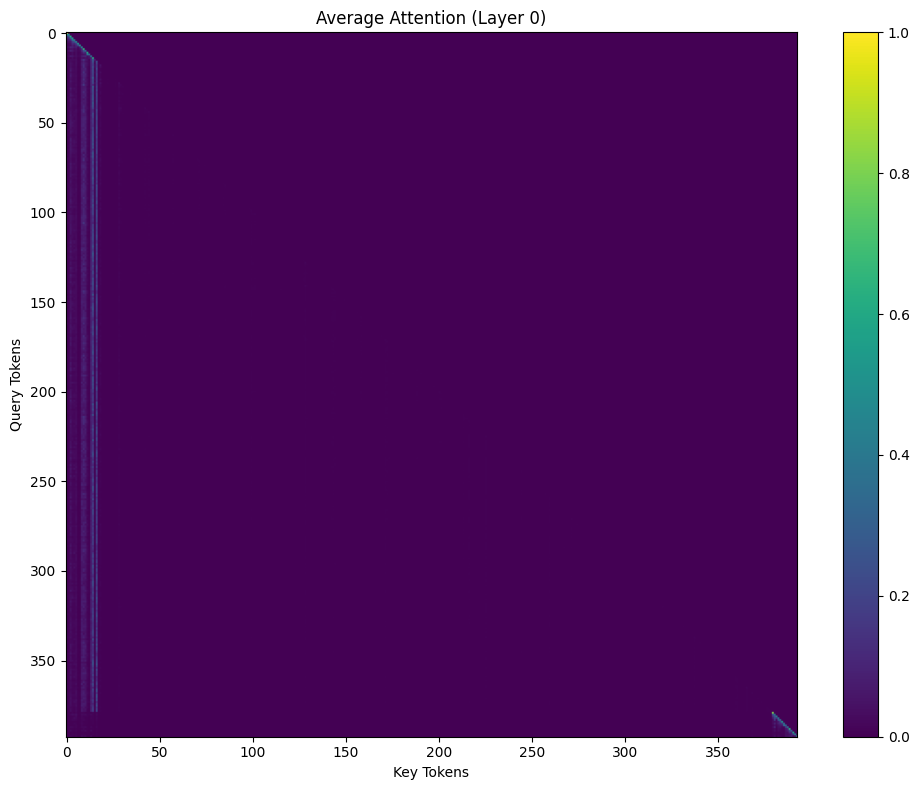

In [19]:
# Visualize Averaged Attention
plt.figure(figsize=(10,8))

plt.imshow(avg_attention, aspect="auto")

plt.colorbar()

plt.title(f"Average Attention (Layer {layer_idx})")

plt.xlabel("Key Tokens")

plt.ylabel("Query Tokens")

plt.tight_layout()

plt.show()

# Step 12: Compute Attention Rollout

## Objective

Combine attention information from all transformer layers into one global attention map.

## Method

For every transformer layer:

1. Average all attention heads.
2. Add the identity matrix (residual connection).
3. Normalize each row.
4. Multiply the attention matrices across all layers.

This produces a single attention matrix representing information flow through the entire transformer.

## Expected Output

A rollout matrix of shape:

(393 × 393)

In [20]:
# Attention Rollout
import torch

num_layers = len(attentions)
seq_len = attentions[0].shape[-1]

rollout = torch.eye(seq_len, device=model.device)

for layer in range(num_layers):

    # Average all heads
    attn = attentions[layer][0].mean(dim=0)

    # Add residual connection
    attn = attn + torch.eye(seq_len, device=attn.device)

    # Normalize rows
    attn = attn / attn.sum(dim=-1, keepdim=True)

    # Accumulate attention
    rollout = attn @ rollout

rollout = rollout.cpu()

print("=" * 60)
print("Attention Rollout")
print("=" * 60)

print("Shape :", rollout.shape)

print("=" * 60)

Attention Rollout
Shape : torch.Size([393, 393])


# Step 13: Cross-Modal Attention Extraction

## Objective
Extract how much each generated answer token attends to each image patch.

## Why teacher-forced forward pass?
The rollout in Step 12 was computed on the input sequence only (image + question).
To get attention FROM answer tokens → image patches, we need to pass the full sequence
(image + question + answer) together and extract attention from answer token rows only.

## Method
1. Append generated answer tokens to the input sequence
2. Run a single teacher-forced forward pass with output_attentions=True
3. Compute attention rollout across all layers on the full sequence
4. Filter rollout: rows = answer token positions, cols = image patch positions
5. Average across answer tokens → one attention score per image patch
6. Reshape to 2D patch grid using image_grid_thw
7. Upsample to original image size and overlay as heatmap

## Expected Output
- Cross-modal attention heatmap overlaid on the original instrument image
- Patch-level attention scores array

Token Sequence Analysis
Total input tokens    : 393
Image patch positions : 15 → 378
Number of patches     : 364
Raw patch grid        : 52 × 28 = 1456
Merge factor          : 4x (2×2 spatial merge)
Token patch grid      : 26 × 14 = 364
Teacher-Forced Forward Pass
Input tokens   : 393
Answer tokens  : 7
Full sequence  : 400
Layers         : 36
Attention shape: torch.Size([1, 16, 400, 400])
Patch grid shape    : (26, 14)
Upsampled shape     : (2291, 1290)  (matches image 2291×1290)


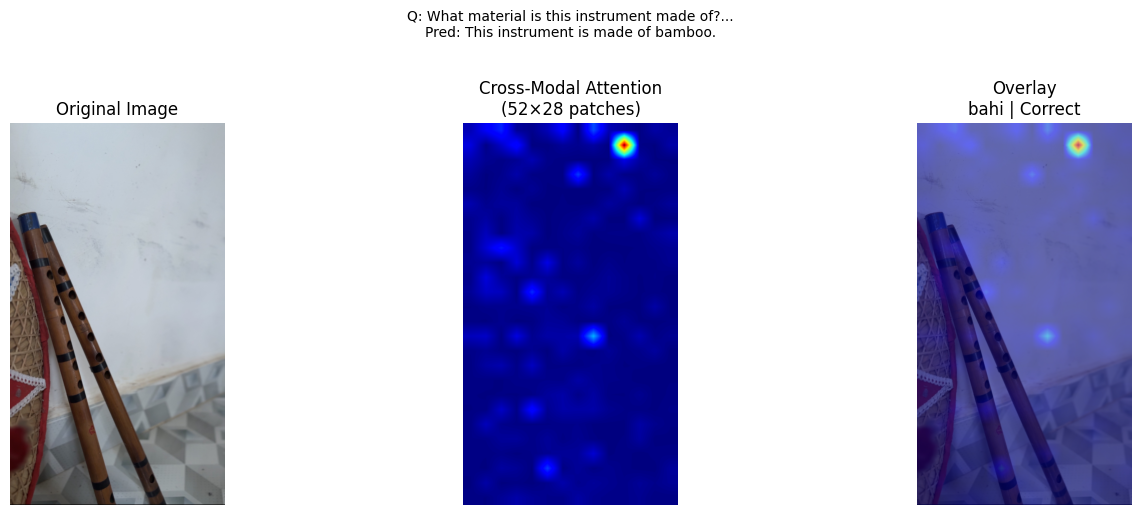

Saved: /kaggle/working/results/explainability/bahi_bahi_test3_attention.png
Scores Stored
Image coverage ratio : 0.0018
Peak patch location  : row=0, col=24


In [21]:
# Step 13: Cross-Modal Attention Extraction

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import os

# ── 1. Identify image patch positions in input sequence ──────────────────────

IMAGE_PAD_TOKEN_ID = 151655

input_ids_list = inputs.input_ids[0].cpu().tolist()
image_patch_positions = [
    i for i, tok in enumerate(input_ids_list) if tok == IMAGE_PAD_TOKEN_ID
]
n_image_patches = len(image_patch_positions)

print("=" * 60)
print("Token Sequence Analysis")
print("=" * 60)
print(f"Total input tokens    : {len(input_ids_list)}")
print(f"Image patch positions : {image_patch_positions[0]} → {image_patch_positions[-1]}")
print(f"Number of patches     : {n_image_patches}")

# ── 2. Get patch grid dimensions from processor ──────────────────────────────

grid_thw = inputs.image_grid_thw[0]   # [T, H, W]
grid_h   = grid_thw[1].item()
grid_w   = grid_thw[2].item()

merge_factor  = (grid_h * grid_w) // n_image_patches
grid_h_tokens = grid_h // 2
grid_w_tokens = grid_w // 2

print(f"Raw patch grid        : {grid_h} × {grid_w} = {grid_h * grid_w}")
print(f"Merge factor          : {merge_factor}x (2×2 spatial merge)")
print(f"Token patch grid      : {grid_h_tokens} × {grid_w_tokens} = {grid_h_tokens * grid_w_tokens}")
assert grid_h_tokens * grid_w_tokens == n_image_patches, \
    f"Mismatch: {grid_h_tokens * grid_w_tokens} vs {n_image_patches}"
print("=" * 60)

# ── 3. Teacher-forced forward pass ───────────────────────────────────────────

# Tokenize the generated prediction (answer tokens only)
answer_token_ids = processor.tokenizer(
    prediction,
    return_tensors="pt",
    add_special_tokens=False,
).input_ids.to(model.device)

n_answer_tokens      = answer_token_ids.shape[1]
n_input_tokens       = inputs.input_ids.shape[1]
answer_start_pos     = n_input_tokens   # answer tokens begin right after input

# Build teacher-forced full sequence
tf_input_ids      = torch.cat([inputs.input_ids, answer_token_ids], dim=1)
tf_attention_mask = torch.ones_like(tf_input_ids)

print("=" * 60)
print("Teacher-Forced Forward Pass")
print("=" * 60)
print(f"Input tokens   : {n_input_tokens}")
print(f"Answer tokens  : {n_answer_tokens}")
print(f"Full sequence  : {tf_input_ids.shape[1]}")

with torch.no_grad():
    tf_outputs = model(
        input_ids       = tf_input_ids,
        attention_mask  = tf_attention_mask,
        pixel_values    = inputs.pixel_values,
        image_grid_thw  = inputs.image_grid_thw,
        output_attentions = True,
        return_dict     = True,
    )

tf_attentions = tf_outputs.attentions
tf_seq_len    = tf_input_ids.shape[1]

answer_positions = list(range(n_input_tokens, n_input_tokens + n_answer_tokens))

print(f"Layers         : {len(tf_attentions)}")
print(f"Attention shape: {tf_attentions[0].shape}")
print("=" * 60)

# Replace rollout with direct attention extraction
# For each layer: get attention from answer token rows → image patch columns
cross_modal_layers = []

for layer_attn in tf_attentions:
    attn = layer_attn[0].mean(dim=0).cpu().float()  # avg heads [seq, seq]
    # answer rows × image patch cols
    cm_layer = attn[answer_positions, :][:, image_patch_positions]
    cross_modal_layers.append(cm_layer)

# Average across layers
cross_modal = torch.stack(cross_modal_layers).mean(dim=0)  # [n_answer, n_patches]
patch_attention = cross_modal.mean(dim=0).numpy()          # [n_patches]

# ── 6. Reshape to 2D grid and upsample ───────────────────────────────────────

orig_image     = Image.open(image_path).convert("RGB")
orig_w, orig_h = orig_image.size

# Reshape flat patch scores → 2D spatial grid
patch_map_2d = patch_attention.reshape(grid_h_tokens, grid_w_tokens)

# Upsample to original image resolution (bilinear)
patch_tensor = torch.tensor(patch_map_2d).unsqueeze(0).unsqueeze(0).float()
upsampled    = F.interpolate(
    patch_tensor,
    size=(orig_h, orig_w),
    mode="bilinear",
    align_corners=False,
).squeeze().numpy()

# Normalize to [0, 1]
attn_norm = (upsampled - upsampled.min()) / (upsampled.max() - upsampled.min() + 1e-8)

print(f"Patch grid shape    : {patch_map_2d.shape}")
print(f"Upsampled shape     : {upsampled.shape}  (matches image {orig_h}×{orig_w})")

# ── 7. Overlay heatmap on original image ─────────────────────────────────────

orig_array    = np.array(orig_image).astype(np.float32) / 255.0
heatmap_rgb   = cm.jet(attn_norm)[:, :, :3]              # apply jet colormap → RGB
overlay       = 0.5 * orig_array + 0.5 * heatmap_rgb     # blend

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(orig_image)
axes[0].set_title("Original Image", fontsize=12)
axes[0].axis("off")

axes[1].imshow(attn_norm, cmap="jet")
axes[1].set_title(f"Cross-Modal Attention\n({grid_h}×{grid_w} patches)", fontsize=12)
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title(
    f"Overlay\n{sample['instrument']} | {sample['failure_category']}",
    fontsize=12
)
axes[2].axis("off")

plt.suptitle(
    f"Q: {sample['question'][:60]}...\nPred: {prediction[:60]}",
    fontsize=10, y=1.02
)
plt.tight_layout()

# Save
os.makedirs("/kaggle/working/results/explainability", exist_ok=True)
save_path = (
    f"/kaggle/working/results/explainability/"
    f"{sample['instrument']}_{sample['image'].replace('.jpg','')}_attention.png"
)
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

# ── 8. Store scores for aggregation ──────────────────────────────────────────

attention_result = {
    "image"              : sample["image"],
    "instrument"         : sample["instrument"],
    "question"           : sample["question"],
    "ground_truth"       : sample["ground_truth"],
    "prediction"         : prediction,
    "failure_category"   : sample["failure_category"],
    "patch_attention"    : patch_attention.tolist(),
    "grid_h"             : grid_h,
    "grid_w"             : grid_w,
    "image_coverage_ratio": float((attn_norm > 0.5).mean()),
    "peak_patch_row"     : int(np.unravel_index(patch_attention.argmax(), (grid_h, grid_w))[0]),
    "peak_patch_col"     : int(np.unravel_index(patch_attention.argmax(), (grid_h, grid_w))[1]),
}

print("=" * 60)
print("Scores Stored")
print("=" * 60)
print(f"Image coverage ratio : {attention_result['image_coverage_ratio']:.4f}")
print(f"Peak patch location  : row={attention_result['peak_patch_row']}, "
      f"col={attention_result['peak_patch_col']}")
print("=" * 60)

# Step 14: Cross-Modal Attribution (Captum Integrated Gradients)

## Objective
Identify which image patch embeddings **causally drive** the first generated answer token.

## Why Integrated Gradients?
Attention shows where the model *looks* — attribution shows what *causes* the output.
Together they give a complete cross-modal explanation.

## Method
1. Get input embeddings of the full sequence (image + question)
2. Define baseline = zero embeddings (represents absence of visual information)
3. Run LayerIntegratedGradients on the embedding layer
4. Target = first generated answer token (most causally informative)
5. Aggregate attribution scores across embedding dimensions per patch
6. Reshape → 2D grid → upsample → overlay

## Expected Output
- Attribution heatmap overlaid on original instrument image
- Patch-level attribution scores array

In [22]:
from PIL import Image
orig_image = Image.open(image_path).convert("RGB")
orig_w, orig_h = orig_image.size

import os
os.makedirs("/kaggle/working/results/explainability", exist_ok=True)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Captum Integrated Gradients
Target token ID  : 1986
Target token     : This
Attributions shape: torch.Size([720, 1176])
min: -5.115121364593506 max: 5.90214729309082 mean: 4.946688932250254e-06
token_attribution shape: (720,)
Patch attribution — min: 1.834491  max: 465.916199  mean: 36.352558
Attribution map shape : (18, 10)
Upsampled shape       : (2291, 1290)


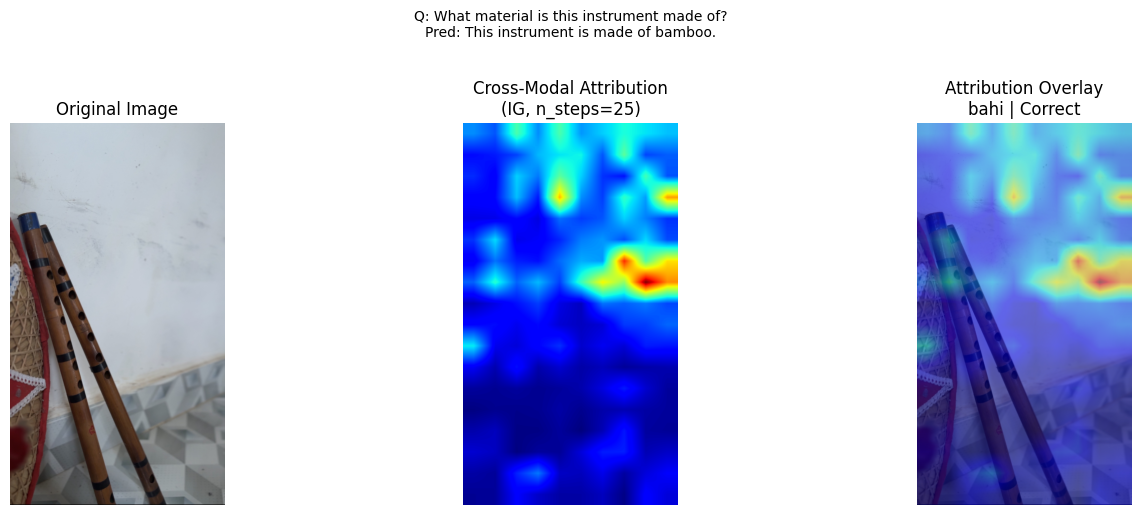

Saved: /kaggle/working/results/explainability/bahi_bahi_test3_attribution.png
Attribution Scores Stored
Coverage ratio : 0.0414
Peak location  : row=7, col=8


In [24]:
# Step 14: Cross-Modal Attribution (Captum Integrated Gradients)

!pip install -q captum

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from captum.attr import LayerIntegratedGradients

model.gradient_checkpointing_enable()
model.enable_input_require_grads()

# ── 1. Define forward function for Captum ────────────────────────────────────

def forward_for_attribution(input_embeds):
    """
    Takes input embeddings, runs model, returns logit of target token.
    Captum calls this repeatedly during IG interpolation.
    """
    outputs = model(
        inputs_embeds   = input_embeds,
        attention_mask  = inputs.attention_mask,
        image_grid_thw  = inputs.image_grid_thw,
        return_dict     = True,
    )
    # Return logit of first generated answer token at last input position
    return outputs.logits[:, -1, target_token_id]

# ── 2. Get target token (first generated answer token) ───────────────────────

target_token_id = processor.tokenizer(
    prediction,
    add_special_tokens=False,
).input_ids[0]

print("=" * 60)
print("Captum Integrated Gradients")
print("=" * 60)
print(f"Target token ID  : {target_token_id}")
print(f"Target token     : {processor.tokenizer.decode([target_token_id])}")

# ── 3. Get input embeddings ───────────────────────────────────────────────────

embedding_layer = model.base_model.model.model.language_model.embed_tokens

# ── . Run LayerIntegratedGradients ──────────────────────────────────────────

from captum.attr import IntegratedGradients

def forward_for_attribution_pixels(pixel_values):
    outputs = model(
        input_ids      = inputs.input_ids,
        attention_mask = inputs.attention_mask,
        image_grid_thw = inputs.image_grid_thw,
        pixel_values   = pixel_values,
        return_dict    = True,
    )
    return outputs.logits[:, -1, target_token_id]

pixel_values = inputs.pixel_values.clone().detach().requires_grad_(True)

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

for param in model.parameters():
    param.requires_grad_(False)

ig = IntegratedGradients(forward_for_attribution_pixels)
attributions = ig.attribute(
    pixel_values,
    baselines=torch.zeros_like(pixel_values),
    n_steps=10,
    internal_batch_size=1   
)

print("Attributions shape:", attributions.shape)
print("min:", attributions.min().item(), "max:", attributions.max().item(), "mean:", attributions.mean().item())


# ── 6. Aggregate attribution per raw patch ────────────────────────────────
token_attribution = attributions.squeeze(0).abs().sum(dim=-1).detach().cpu().float().numpy()
# shape should be [1456] (52*28 raw patches) — check this first:
print("token_attribution shape:", token_attribution.shape)

patch_attribution = token_attribution  # already patch-level, no filtering needed

print(f"Patch attribution — min: {patch_attribution.min():.6f}  "
      f"max: {patch_attribution.max():.6f}  "
      f"mean: {patch_attribution.mean():.6f}")

# ── 7. Reshape to raw grid, then downsample to merged grid to match attention map ──
raw_grid_h, raw_grid_w = 36, 20  # adjust if your image gives different raw grid
attr_map_2d_raw = token_attribution.reshape(raw_grid_h, raw_grid_w)

# average-pool 2x2 to match merged grid_h_tokens/grid_w_tokens (26,14)
attr_tensor_raw = torch.tensor(attr_map_2d_raw).unsqueeze(0).unsqueeze(0).float()
attr_map_2d = F.avg_pool2d(attr_tensor_raw, kernel_size=2, stride=2).squeeze().numpy()

attr_tensor  = torch.tensor(attr_map_2d).unsqueeze(0).unsqueeze(0).float()
attr_upsampled = F.interpolate(
    attr_tensor,
    size=(orig_h, orig_w),
    mode="bilinear",
    align_corners=False,
).squeeze().numpy()

attr_norm = (attr_upsampled - attr_upsampled.min()) / \
            (attr_upsampled.max() - attr_upsampled.min() + 1e-8)

print(f"Attribution map shape : {attr_map_2d.shape}")
print(f"Upsampled shape       : {attr_upsampled.shape}")
# ── 8. Overlay on original image ─────────────────────────────────────────────

orig_array   = np.array(orig_image).astype(np.float32) / 255.0
heatmap_rgb  = cm.jet(attr_norm)[:, :, :3]
overlay_attr = 0.5 * orig_array + 0.5 * heatmap_rgb

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(orig_image)
axes[0].set_title("Original Image", fontsize=12)
axes[0].axis("off")

axes[1].imshow(attr_norm, cmap="jet")
axes[1].set_title(
    f"Cross-Modal Attribution\n(IG, n_steps=25)",
    fontsize=12
)
axes[1].axis("off")

axes[2].imshow(overlay_attr)
axes[2].set_title(
    f"Attribution Overlay\n{sample['instrument']} | {sample['failure_category']}",
    fontsize=12
)
axes[2].axis("off")

plt.suptitle(
    f"Q: {sample['question'][:60]}\nPred: {prediction[:60]}",
    fontsize=10, y=1.02
)
plt.tight_layout()

save_path_attr = (
    f"/kaggle/working/results/explainability/"
    f"{sample['instrument']}_{sample['image'].replace('.jpg','')}_attribution.png"
)
plt.savefig(save_path_attr, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path_attr}")

# ── 9. Store attribution scores ───────────────────────────────────────────────

attribution_result = {
    "image"                    : sample["image"],
    "instrument"               : sample["instrument"],
    "question"                 : sample["question"],
    "ground_truth"             : sample["ground_truth"],
    "prediction"               : prediction,
    "failure_category"         : sample["failure_category"],
    "patch_attribution"        : attr_map_2d.flatten().tolist(),
    "grid_h"                   : raw_grid_h,
    "grid_w"                   : raw_grid_w,
    "attribution_coverage_ratio": float((attr_norm > 0.5).mean()),
    "peak_attr_row"            : int(np.unravel_index(attr_map_2d.argmax(), attr_map_2d.shape)[0]),
    "peak_attr_col"            : int(np.unravel_index(attr_map_2d.argmax(), attr_map_2d.shape)[1]),
    "n_steps"                  : 10,
}

print("=" * 60)
print("Attribution Scores Stored")
print("=" * 60)
print(f"Coverage ratio : {attribution_result['attribution_coverage_ratio']:.4f}")
print(f"Peak location  : row={attribution_result['peak_attr_row']}, "
      f"col={attribution_result['peak_attr_col']}")
print("=" * 60)

# Step 15: Batch Explainability — All 35 Samples

## Objective
Run cross-modal attention (Step 13) and cross-modal attribution (Step 14) on all 35
curated samples, spanning all 7 failure categories across all 7 instruments.

## Why two separate passes
Attention extraction (36-layer output_attentions) and attribution (Captum IG with
gradient tracking) each consume close to the T4's 16GB limit individually. Running
both in the same session causes CUDA OOM. Each pass reloads the model fresh and
processes all 35 samples before the session ends.

## Pass A — Cross-Modal Attention (this step)
For each of the 35 samples:
1. Run inference to get the model's prediction
2. Identify image patch token positions
3. Run a teacher-forced forward pass (input + generated answer together)
4. Extract per-layer attention from answer tokens → image patch tokens, averaged
   across layers and answer tokens (not rollout — causal masking breaks rollout
   across the input→answer boundary, confirmed in Step 13)
5. Reshape to spatial grid, upsample to original image size, overlay as heatmap
6. Save heatmap PNG + scores (patch attention array, coverage ratio, peak location)

Failed samples are caught and logged without stopping the loop — errors don't halt
the batch, they're recorded in the output JSON for later review.

## Pass B — Cross-Modal Attribution (next session, separate)
Same 35 samples, Captum Integrated Gradients on pixel_values, run in a fresh
session after Pass A completes and the kernel is restarted.

## Output
```
results/explainability/
├── attention/
│   ├── bahi_bahi_test1_attention.png
│   ├── ... (35 heatmap images)
└── attention_results.json   ← all 35 samples' scores, ready for Step 16 aggregation
```

## Expected Output
`35/35 processed` with per-sample coverage ratio and peak patch location printed
during the loop, and a consolidated JSON file for downstream failure-category
aggregation (Step 16).

In [9]:
import gc
del model, base_model
gc.collect()
torch.cuda.empty_cache()

from transformers import Qwen2_5_VLForConditionalGeneration
from peft import PeftModel

base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="eager",
)
model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
model = model.merge_and_unload()
model.eval()
print("✓ Model reloaded with eager attention")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/config.py:165: UserWarning: Unexpected keyword arguments ['alora_invocation_tokens', 'arrow_config', 'ensure_weight_tying', 'lora_ga_config', 'peft_version', 'use_bdlora'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


✓ Model reloaded with eager attention


In [10]:
# Run in fresh session. Steps 1-4 (env, paths, processor, base model) already done.
# Reload model in eager attention mode ONCE, loop all samples.

import gc, os, json
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
from qwen_vl_utils import process_vision_info

os.makedirs("/kaggle/working/results/explainability/attention", exist_ok=True)
IMAGE_PAD_TOKEN_ID = 151655

all_attention_results = []

for idx, sample in samples.iterrows():
    print(f"\n[{idx+1}/35] {sample['instrument']} — {sample['image']}")

    try:
        image_path = os.path.join(TEST_DIR, sample["instrument"], sample["image"])
        question = sample["question"]

        messages = [{
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": question},
            ],
        }]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = processor(text=[text], images=image_inputs, videos=video_inputs,
                            padding=True, return_tensors="pt").to(model.device)

        # Generate prediction
        with torch.no_grad():
            gen_ids = model.generate(**inputs, max_new_tokens=64, do_sample=False)
        gen_ids = gen_ids[:, inputs.input_ids.shape[1]:]
        prediction = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]

        # Image patch positions
        input_ids_list = inputs.input_ids[0].cpu().tolist()
        image_patch_positions = [i for i, t in enumerate(input_ids_list) if t == IMAGE_PAD_TOKEN_ID]
        n_image_patches = len(image_patch_positions)

        grid_thw = inputs.image_grid_thw[0]
        grid_h, grid_w = grid_thw[1].item(), grid_thw[2].item()
        grid_h_tokens, grid_w_tokens = grid_h // 2, grid_w // 2
        assert grid_h_tokens * grid_w_tokens == n_image_patches

        # Teacher-forced pass
        answer_ids = processor.tokenizer(prediction, return_tensors="pt", add_special_tokens=False).input_ids.to(model.device)
        n_input_tokens = inputs.input_ids.shape[1]
        n_answer_tokens = answer_ids.shape[1]
        tf_input_ids = torch.cat([inputs.input_ids, answer_ids], dim=1)
        tf_attention_mask = torch.ones_like(tf_input_ids)
        answer_positions = list(range(n_input_tokens, n_input_tokens + n_answer_tokens))

        with torch.no_grad():
            tf_outputs = model(
                input_ids=tf_input_ids, attention_mask=tf_attention_mask,
                pixel_values=inputs.pixel_values, image_grid_thw=inputs.image_grid_thw,
                output_attentions=True, return_dict=True,
            )
        tf_attentions = tf_outputs.attentions

        # Cross-modal attention
        cross_modal_layers = []
        for layer_attn in tf_attentions:
            attn = layer_attn[0].mean(dim=0).cpu().float()
            cm_layer = attn[answer_positions, :][:, image_patch_positions]
            cross_modal_layers.append(cm_layer)
        cross_modal = torch.stack(cross_modal_layers).mean(dim=0)
        patch_attention = cross_modal.mean(dim=0).numpy()

        # Reshape + upsample
        orig_image = Image.open(image_path).convert("RGB")
        orig_w, orig_h = orig_image.size
        patch_map_2d = patch_attention.reshape(grid_h_tokens, grid_w_tokens)
        attn_tensor = torch.tensor(patch_map_2d).unsqueeze(0).unsqueeze(0).float()
        upsampled = F.interpolate(attn_tensor, size=(orig_h, orig_w), mode="bilinear", align_corners=False).squeeze().numpy()
        attn_norm = (upsampled - upsampled.min()) / (upsampled.max() - upsampled.min() + 1e-8)

        # Save heatmap
        import matplotlib.pyplot as plt
        import matplotlib.cm as cm
        orig_array = np.array(orig_image).astype(np.float32) / 255.0
        overlay = 0.5 * orig_array + 0.5 * cm.jet(attn_norm)[:, :, :3]

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(orig_image); axes[0].set_title("Original"); axes[0].axis("off")
        axes[1].imshow(overlay); axes[1].set_title(f"{sample['instrument']} | {sample['failure_category']}"); axes[1].axis("off")
        plt.tight_layout()
        fname = f"{sample['instrument']}_{sample['image'].replace('.jpg','').replace('.jpeg','')}"
        plt.savefig(f"/kaggle/working/results/explainability/attention/{fname}_attention.png", dpi=120, bbox_inches="tight")
        plt.close()

        all_attention_results.append({
            "image": sample["image"], "instrument": sample["instrument"],
            "question": sample["question"], "ground_truth": sample["ground_truth"],
            "prediction": prediction, "failure_category": sample["failure_category"],
            "patch_attention": patch_attention.tolist(),
            "grid_h": grid_h_tokens, "grid_w": grid_w_tokens,
            "image_coverage_ratio": float((attn_norm > 0.5).mean()),
            "peak_patch_row": int(np.unravel_index(patch_attention.argmax(), (grid_h_tokens, grid_w_tokens))[0]),
            "peak_patch_col": int(np.unravel_index(patch_attention.argmax(), (grid_h_tokens, grid_w_tokens))[1]),
        })
        print(f"  ✓ coverage={all_attention_results[-1]['image_coverage_ratio']:.4f}")

    except Exception as e:
        print(f"  ✗ FAILED: {e}")
        all_attention_results.append({"image": sample["image"], "instrument": sample["instrument"], "error": str(e)})

    # Free memory every sample
    del tf_outputs, tf_attentions, cross_modal_layers, cross_modal
    gc.collect()
    torch.cuda.empty_cache()

# Save all results
with open("/kaggle/working/results/explainability/attention_results.json", "w") as f:
    json.dump(all_attention_results, f, indent=2)

print(f"\n{'='*60}\nDone: {len(all_attention_results)}/35 processed\n{'='*60}")


[1/35] bahi — bahi_test3.jpg


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  ✓ coverage=0.0036

[2/35] bahi — bahi_test5.jpg


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  ✓ coverage=0.0047


...


[33/35] gogona — gogona_test4.jpg
  ✓ coverage=0.0059


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



[34/35] gogona — gogona_test1.jpg
  ✓ coverage=0.0046


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



[35/35] gogona — gogona_test5.jpg
  ✓ coverage=0.0089

Done: 35/35 processed


In [11]:
import os

# Zip results folder
!zip -r /kaggle/working/attention_results.zip /kaggle/working/results/explainability/

# Verify
print(os.path.getsize("/kaggle/working/attention_results.zip") / 1e6, "MB")

  adding: kaggle/working/results/explainability/ (stored 0%)
  adding: kaggle/working/results/explainability/attention/ (stored 0%)
  adding: kaggle/working/results/explainability/attention/bahi_bahi_test2_attention.png (deflated 0%)
  adding: kaggle/working/results/explainability/attention/gogona_gogona_test5_attention.png (deflated 1%)
  adding: kaggle/working/results/explainability/attention/gogona_gogona_test3_attention.png (deflated 0%)
  adding: kaggle/working/results/explainability/attention/gogona_gogona_test4_attention.png

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


 (deflated 0%)
  adding: kaggle/working/results/explainability/attention/khutitaal_khutitaal_test1_attention.png (deflated 0%)
  adding: kaggle/working/results/explainability/attention/toka_toka_test1_attention.png (deflated 0%)
  adding: kaggle/working/results/explainability/attention/toka_toka_test4_attention.png (deflated 1%)
  adding: kaggle/working/results/explainability/attention/gogona_gogona_test1_attention.png (deflated 0%)
  adding: kaggle/working/results/explainability/attention/xutuli_xutuli_test3_attention.png (deflated 0%)
  adding: kaggle/working/results/explainability/attention/bahi_bahi_test5_attention.png (deflated 0%)
  adding: kaggle/working/results/explainability/attention/xutuli_xutuli_test4_attention.png (deflated 0%)
  adding: kaggle/working/results/explainability/attention/pepa_pepa_test2_attention.png (deflated 0%)
  adding: kaggle/working/results/explainability/attention/bihu_dhol_bihu_dhol_test4_attention.png (deflated 0%)
  adding: kaggle/working/results/ex

In [8]:
!pip install -q captum

import gc, os, json
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from qwen_vl_utils import process_vision_info
from captum.attr import IntegratedGradients

del model, base_model
gc.collect()
torch.cuda.empty_cache()

from transformers import Qwen2_5_VLForConditionalGeneration
from peft import PeftModel

base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="eager",
)
model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
model = model.merge_and_unload()
model.eval()
print("✓ Model reloaded with eager attention")

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
os.makedirs("/kaggle/working/results/explainability/attribution", exist_ok=True)

model.gradient_checkpointing_enable()
model.enable_input_require_grads()
for param in model.parameters():
    param.requires_grad_(False)

all_attribution_results = []

for idx, sample in samples.iterrows():
    print(f"\n[{idx+1}/35] {sample['instrument']} — {sample['image']}")

    try:
        image_path = os.path.join(TEST_DIR, sample["instrument"], sample["image"])
        question = sample["question"]

        messages = [{
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": question},
            ],
        }]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = processor(text=[text], images=image_inputs, videos=video_inputs,
                            padding=True, return_tensors="pt").to(model.device)

        with torch.no_grad():
            gen_ids = model.generate(**inputs, max_new_tokens=64, do_sample=False)
        gen_ids = gen_ids[:, inputs.input_ids.shape[1]:]
        prediction = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]

        target_token_id = processor.tokenizer(prediction, add_special_tokens=False).input_ids[0]

        def forward_for_attribution_pixels(pixel_values):
            outputs = model(
                input_ids=inputs.input_ids, attention_mask=inputs.attention_mask,
                image_grid_thw=inputs.image_grid_thw, pixel_values=pixel_values,
                return_dict=True,
            )
            return outputs.logits[:, -1, target_token_id]

        pixel_values = inputs.pixel_values.clone().detach().requires_grad_(True)

        ig = IntegratedGradients(forward_for_attribution_pixels)
        attributions = ig.attribute(pixel_values, baselines=torch.zeros_like(pixel_values),
                             n_steps=50, internal_batch_size=1)

        token_attribution = attributions.squeeze(0).abs().sum(dim=-1).detach().cpu().float().numpy()

        grid_thw = inputs.image_grid_thw[0]
        raw_grid_h, raw_grid_w = grid_thw[1].item(), grid_thw[2].item()
        attr_map_2d = token_attribution.reshape(raw_grid_h, raw_grid_w)

        orig_image = Image.open(image_path).convert("RGB")
        orig_w, orig_h = orig_image.size
        attr_tensor = torch.tensor(attr_map_2d).unsqueeze(0).unsqueeze(0).float()
        attr_upsampled = F.interpolate(attr_tensor, size=(orig_h, orig_w), mode="bilinear", align_corners=False).squeeze().numpy()
        attr_norm = (attr_upsampled - attr_upsampled.min()) / (attr_upsampled.max() - attr_upsampled.min() + 1e-8)

        orig_array = np.array(orig_image).astype(np.float32) / 255.0
        overlay_attr = 0.5 * orig_array + 0.5 * cm.jet(attr_norm)[:, :, :3]

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(orig_image); axes[0].set_title("Original"); axes[0].axis("off")
        axes[1].imshow(overlay_attr); axes[1].set_title(f"{sample['instrument']} | {sample['failure_category']}"); axes[1].axis("off")
        plt.tight_layout()
        fname = f"{sample['instrument']}_{sample['image'].replace('.jpg','').replace('.jpeg','')}"
        plt.savefig(f"/kaggle/working/results/explainability/attribution/{fname}_attribution.png", dpi=120, bbox_inches="tight")
        plt.close()

        all_attribution_results.append({
            "image": sample["image"], "instrument": sample["instrument"],
            "question": sample["question"], "ground_truth": sample["ground_truth"],
            "prediction": prediction, "failure_category": sample["failure_category"],
            "patch_attribution": attr_map_2d.flatten().tolist(),
            "grid_h": raw_grid_h, "grid_w": raw_grid_w,
            "attribution_coverage_ratio": float((attr_norm > 0.5).mean()),
            "peak_attr_row": int(np.unravel_index(attr_map_2d.argmax(), attr_map_2d.shape)[0]),
            "peak_attr_col": int(np.unravel_index(attr_map_2d.argmax(), attr_map_2d.shape)[1]),
            "n_steps": 50,
        })
        print(f"  ✓ coverage={all_attribution_results[-1]['attribution_coverage_ratio']:.4f}")

    except Exception as e:
        print(f"  ✗ FAILED: {e}")
        all_attribution_results.append({"image": sample["image"], "instrument": sample["instrument"], "error": str(e)})

    gc.collect()
    torch.cuda.empty_cache()

with open("/kaggle/working/results/explainability/attribution_results.json", "w") as f:
    json.dump(all_attribution_results, f, indent=2)

print(f"\n{'='*60}\nDone: {len(all_attribution_results)}/35 processed\n{'='*60}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 9.2 MB/s eta 0:00:00:00:01


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/config.py:165: UserWarning: Unexpected keyword arguments ['alora_invocation_tokens', 'arrow_config', 'ensure_weight_tying', 'lora_ga_config', 'peft_version', 'use_bdlora'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


✓ Model reloaded with eager attention

[1/35] bahi — bahi_test3.jpg


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 720 equal to the number of examples.
  warnings.warn(


...

  ✓ coverage=0.0013

[33/35] gogona — gogona_test4.jpg


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  ✓ coverage=0.0016

[34/35] gogona — gogona_test1.jpg


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  ✓ coverage=0.0010

[35/35] gogona — gogona_test5.jpg
  ✓ coverage=0.0009

Done: 35/35 processed


In [9]:
!zip -r /kaggle/working/attribution_results_n50.zip /kaggle/working/results/explainability/

  adding: kaggle/working/results/explainability/ (stored 0%)
  adding: kaggle/working/results/explainability/attribution/ (stored 0%)
  adding: kaggle/working/results/explainability/attribution/pepa_pepa_test5_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/bihu_dhol_bihu_dhol_test5_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/toka_toka_test1_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/xutuli_xutuli_test4_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/bahi_bahi_test3_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/bahi_bahi_test2_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/gogona_gogona_test2_attribution.png

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


 (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/toka_toka_test5_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/xutuli_xutuli_test2_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/bihu_dhol_bihu_dhol_test3_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/gogona_gogona_test1_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/toka_toka_test2_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/khutitaal_khutitaal_test2_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/bahi_bahi_test5_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/xutuli_xutuli_test1_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/khutitaal_khutitaal_test5_attribution.png (de

# Step 16: Aggregate Analysis + Publication Figure

## Objective
Combine per-sample attention and attribution results (Steps 13-15) into
category-level and instrument-level summaries, and produce the key publication
figure connecting explainability patterns to the failure taxonomy.

## What this step does
1. Loads `attention_results.json` and `attribution_results.json` (35 samples each)
2. Filters out any failed samples from the batch run
3. Computes average image coverage ratio (attention and attribution) per failure
   category — CTR, CREP, CQM, CMA, CHA, CPA, Ccorrect
4. Computes average attention coverage and failure-category distribution per
   instrument
5. Builds a 7-panel grid showing one representative attention heatmap per failure
   category — the central figure connecting explainability to the taxonomy
6. Builds a bar chart comparing attention vs attribution coverage across
   categories, showing whether grounding weakens for specific failure types

## Why this matters
Individual sample heatmaps (Steps 13-15) show local behavior. Aggregating by
failure category reveals systematic patterns — e.g. whether hallucinated answers
(CHA) consistently show more diffuse/background attention than correct answers,
which is the core evidence connecting cross-modal grounding to failure mode.

## Output
```
results/explainability/
├── category_summary.csv
├── instrument_summary.csv
├── category_grid_attention.png       ← key publication figure
└── category_coverage_comparison.png
```

## Expected Output
A printed table of per-category and per-instrument coverage statistics, and two
saved figures summarizing cross-modal grounding across the full taxonomy.

Attention results: 35/35
Attribution results: 35/35
                          category  n_samples  avg_attention_coverage  avg_attribution_coverage
                           Correct          7                  0.0099                    0.0025
         Question Misunderstanding          7                  0.0048                    0.0027
                     Hallucination          5                  0.0122                    0.0020
Partial Answer / Incomplete Answer          4                  0.0068                    0.0020
                        Truncation          6                  0.0062                    0.0025
                        Repetition          2                  0.0097                    0.0019
                   Mixed Attribute          4                  0.0147                    0.0021
instrument  n_samples  avg_attention_coverage                                                                                                           failure_distribution
      b

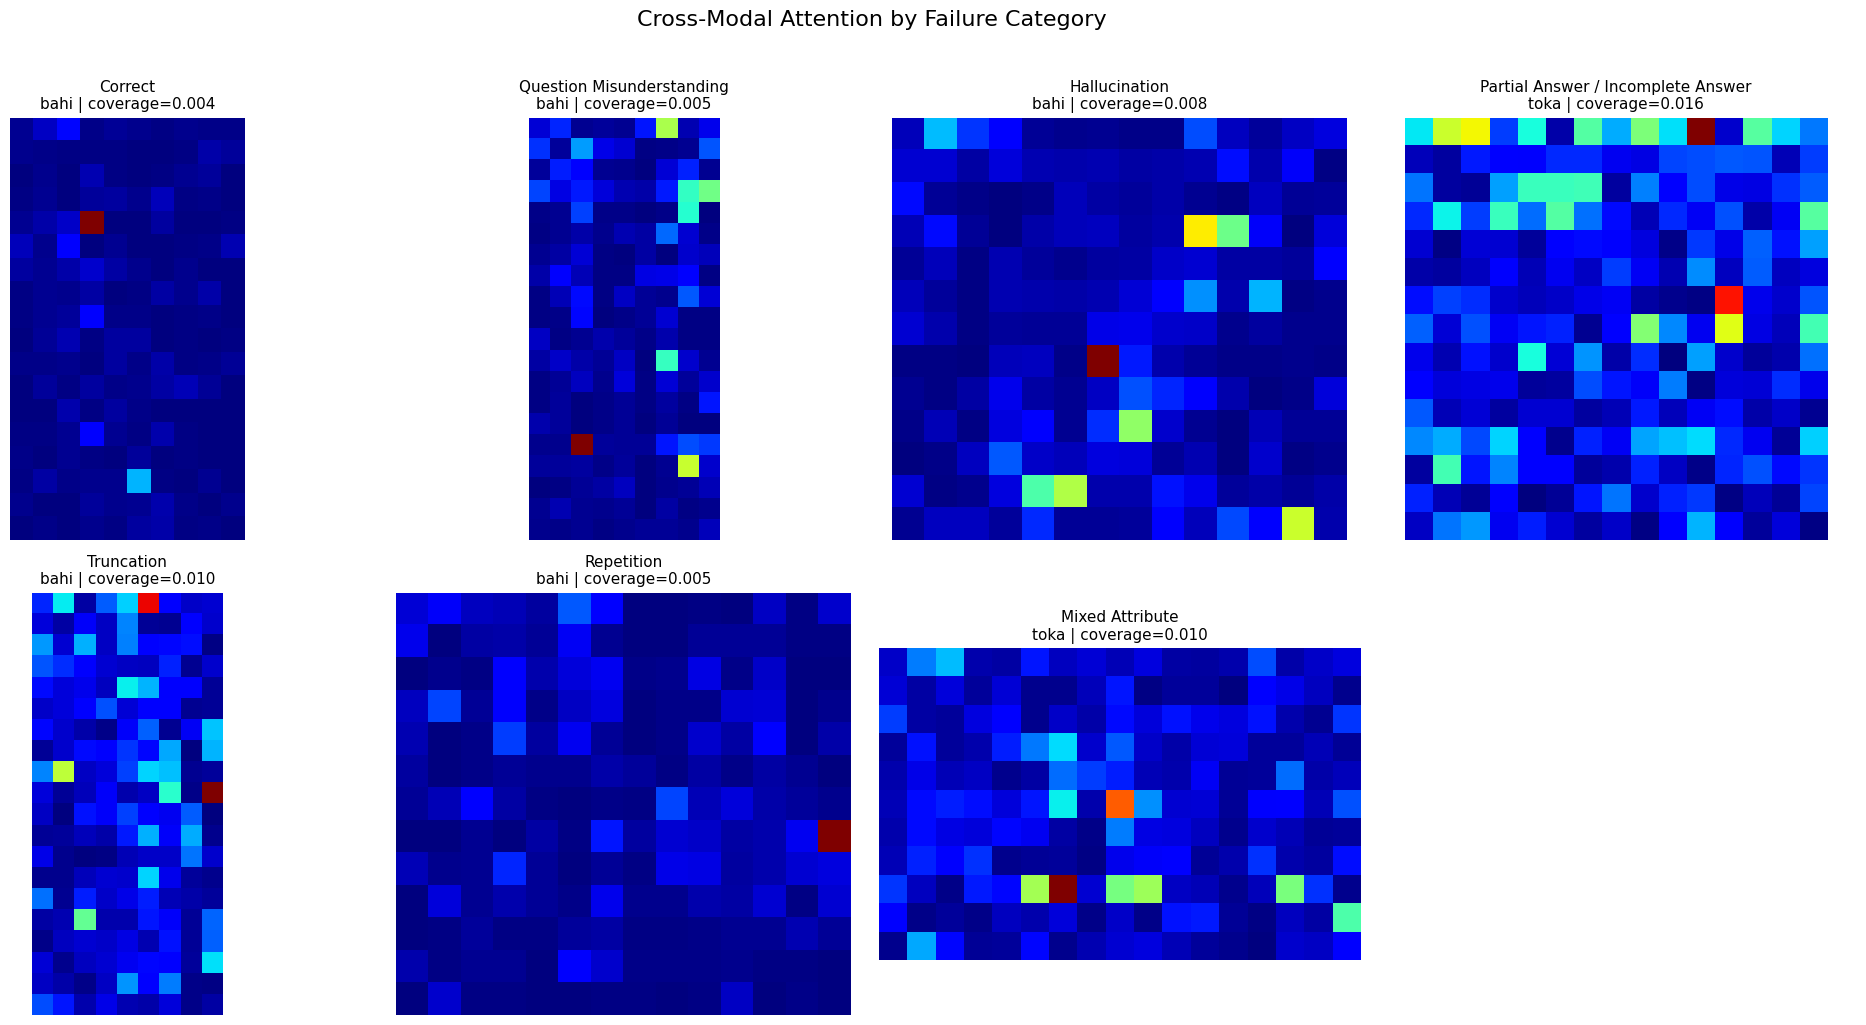

Saved: category_grid_attention.png


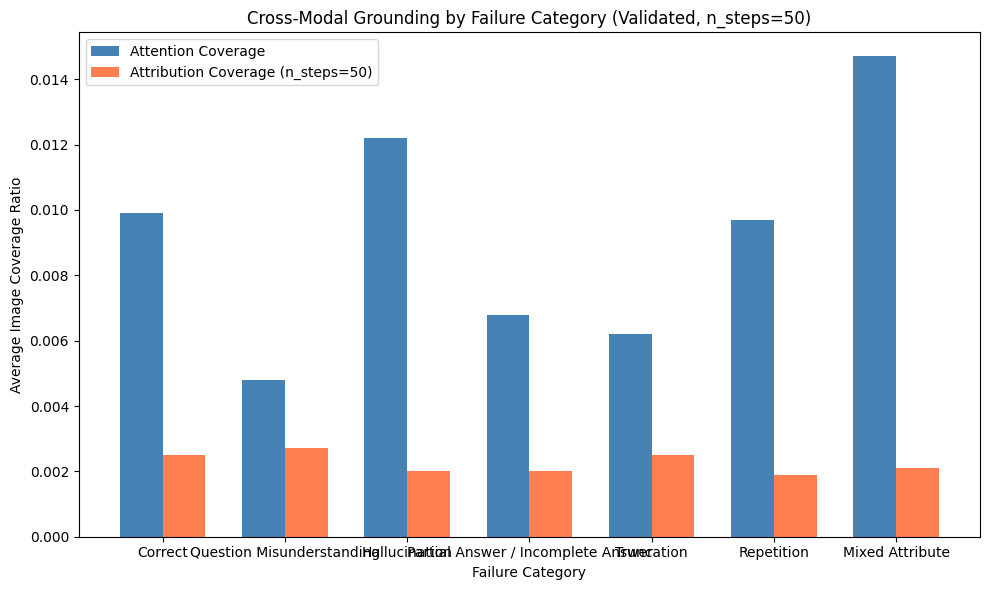

Saved: category_coverage_comparison.png

Step 16 Complete


In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import defaultdict
import pandas as pd

# Load both result sets
with open("/kaggle/input/datasets/bbeastboy/attention-attribution/kaggle_attention/working/results/explainability/attention_results.json") as f:
    attention_results = json.load(f)

with open("/kaggle/input/datasets/bbeastboy/attention-attribution/kaggle_attribution/working/results/explainability/attribution_results.json") as f:
    attribution_results = json.load(f)

# Filter out failed samples
attention_results = [r for r in attention_results if "error" not in r]
attribution_results = [r for r in attribution_results if "error" not in r]

print(f"Attention results: {len(attention_results)}/35")
print(f"Attribution results: {len(attribution_results)}/35")

# ── Per Failure Category Aggregation ──────────────────────────────────────

categories = [
    "Correct",
    "Question Misunderstanding",
    "Hallucination",
    "Partial Answer / Incomplete Answer",
    "Truncation",
    "Repetition",
    "Mixed Attribute",
]

category_stats = []
for cat in categories:
    attn_cat = [r for r in attention_results if r["failure_category"] == cat]
    attr_cat = [r for r in attribution_results if r["failure_category"] == cat]

    if not attn_cat:
        continue

    avg_coverage = np.mean([r["image_coverage_ratio"] for r in attn_cat])
    avg_attr_coverage = np.mean([r["attribution_coverage_ratio"] for r in attr_cat]) if attr_cat else 0

    category_stats.append({
        "category": cat,
        "n_samples": len(attn_cat),
        "avg_attention_coverage": round(avg_coverage, 4),
        "avg_attribution_coverage": round(avg_attr_coverage, 4),
    })

df_categories = pd.DataFrame(category_stats)
print(df_categories.to_string(index=False))
df_categories.to_csv("/kaggle/working/results/explainability/category_summary_n50.csv", index=False)

# ── Per Instrument Aggregation ────────────────────────────────────────────

instruments = sorted(set(r["instrument"] for r in attention_results))
instrument_stats = []
for inst in instruments:
    attn_inst = [r for r in attention_results if r["instrument"] == inst]
    avg_coverage = np.mean([r["image_coverage_ratio"] for r in attn_inst])
    cat_dist = defaultdict(int)
    for r in attn_inst:
        cat_dist[r["failure_category"]] += 1

    instrument_stats.append({
        "instrument": inst,
        "n_samples": len(attn_inst),
        "avg_attention_coverage": round(avg_coverage, 4),
        "failure_distribution": dict(cat_dist),
    })

df_instruments = pd.DataFrame(instrument_stats)
print(df_instruments.to_string(index=False))
df_instruments.to_csv("/kaggle/working/results/explainability/instrument_summary.csv", index=False)

# ── KEY PUBLICATION FIGURE: 7-Category Grid ───────────────────────────────
# Shows one representative attention heatmap per failure category

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, cat in enumerate(categories):
    cat_samples = [r for r in attention_results if r["failure_category"] == cat]
    if not cat_samples:
        axes[i].axis("off")
        continue

    # Pick first sample in category as representative
    rep = cat_samples[0]
    patch_attn = np.array(rep["patch_attention"]).reshape(rep["grid_h"], rep["grid_w"])

    axes[i].imshow(patch_attn, cmap="jet")
    axes[i].set_title(
        f"{cat}\n{rep['instrument']} | coverage={rep['image_coverage_ratio']:.3f}",
        fontsize=11
    )
    axes[i].axis("off")

# Hide unused subplot
if len(categories) < len(axes):
    for j in range(len(categories), len(axes)):
        axes[j].axis("off")

plt.suptitle("Cross-Modal Attention by Failure Category", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/results/explainability/category_grid_attention.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: category_grid_attention.png")

# ── Coverage Comparison Bar Chart ─────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_categories))
width = 0.35

ax.bar(x - width/2, df_categories["avg_attention_coverage"], width, label="Attention Coverage", color="steelblue")
ax.bar(x + width/2, df_categories["avg_attribution_coverage"], width, label="Attribution Coverage (n_steps=50)", color="coral")

ax.set_xlabel("Failure Category")
ax.set_ylabel("Average Image Coverage Ratio")
ax.set_title("Cross-Modal Grounding by Failure Category (Validated, n_steps=50)")
ax.set_xticks(x)
ax.set_xticklabels(df_categories["category"])
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/results/explainability/category_coverage_comparison_n50.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: category_coverage_comparison.png")

print("\n" + "=" * 60)
print("Step 16 Complete")
print("=" * 60)

In [13]:
!zip -r /kaggle/working/step16_results_n50.zip /kaggle/working/results/explainability/

  adding: kaggle/working/results/explainability/ (stored 0%)
  adding: kaggle/working/results/explainability/category_grid_attention.png (deflated 30%)
  adding: kaggle/working/results/explainability/instrument_summary.csv (deflated 72%)
  adding: kaggle/working/results/explainability/attribution/ (stored 0%)
  adding: kaggle/working/results/explainability/attribution/pepa_pepa_test5_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/bihu_dhol_bihu_dhol_test5_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/toka_toka_test1_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/xutuli_xutuli_test4_attribution.png

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


 (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/bahi_bahi_test3_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/bahi_bahi_test2_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/gogona_gogona_test2_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/toka_toka_test5_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/xutuli_xutuli_test2_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/bihu_dhol_bihu_dhol_test3_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/gogona_gogona_test1_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/toka_toka_test2_attribution.png (deflated 0%)
  adding: kaggle/working/results/explainability/attribution/khutitaal_khutitaal_test2_attribution.png (deflated 0%)

# Step 17: Attribution Stability Validation

## Objective
Confirm that n_steps=10-25 for Integrated Gradients gives stable, reliable
attribution — not noisy artifacts of too few interpolation steps.

## Method
Rerun IG on 3-5 samples at n_steps=50, compare against the original n_steps=10
results using cosine similarity between the flattened attribution maps.
Cosine similarity > 0.9 = stable (few steps are sufficient).
Below 0.9 = results are sensitive to step count, report n_steps=50 as final
in the paper instead.

## Expected Output
Per-sample cosine similarity scores + overall stability verdict.

In [17]:
import gc, os, json
import torch
import numpy as np
from PIL import Image
from qwen_vl_utils import process_vision_info
from captum.attr import IntegratedGradients

# Pick 5 diverse samples (different failure categories) for validation
validation_samples = samples.groupby("failure_category").first().reset_index().head(5)
print(f"Validating on {len(validation_samples)} samples")

model.gradient_checkpointing_enable()
model.enable_input_require_grads()
for param in model.parameters():
    param.requires_grad_(False)

stability_results = []

for idx, sample in validation_samples.iterrows():
    print(f"\n[{idx+1}/{len(validation_samples)}] {sample['instrument']} — {sample['failure_category']}")

    image_path = os.path.join(TEST_DIR, sample["instrument"], sample["image"])
    question = sample["question"]

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {"type": "text", "text": question},
        ],
    }]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(text=[text], images=image_inputs, videos=video_inputs,
                        padding=True, return_tensors="pt").to(model.device)

    with torch.no_grad():
        gen_ids = model.generate(**inputs, max_new_tokens=64, do_sample=False)
    gen_ids = gen_ids[:, inputs.input_ids.shape[1]:]
    prediction = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    target_token_id = processor.tokenizer(prediction, add_special_tokens=False).input_ids[0]

    def forward_fn(pixel_values):
        outputs = model(
            input_ids=inputs.input_ids, attention_mask=inputs.attention_mask,
            image_grid_thw=inputs.image_grid_thw, pixel_values=pixel_values,
            return_dict=True,
        )
        return outputs.logits[:, -1, target_token_id]

    pixel_values = inputs.pixel_values.clone().detach().requires_grad_(True)
    ig = IntegratedGradients(forward_fn)

    # n_steps = 10 (original)
    attr_10 = ig.attribute(pixel_values, baselines=torch.zeros_like(pixel_values),
                            n_steps=10, internal_batch_size=1)
    map_10 = attr_10.squeeze(0).abs().sum(dim=-1).detach().cpu().float().numpy()

    del attr_10
    gc.collect()
    torch.cuda.empty_cache()

    # n_steps = 50 (validation)
    attr_50 = ig.attribute(pixel_values, baselines=torch.zeros_like(pixel_values),
                            n_steps=50, internal_batch_size=1)
    map_50 = attr_50.squeeze(0).abs().sum(dim=-1).detach().cpu().float().numpy()

    # Cosine similarity between the two attribution maps
    cos_sim = np.dot(map_10, map_50) / (np.linalg.norm(map_10) * np.linalg.norm(map_50) + 1e-8)

    stability_results.append({
        "image": sample["image"],
        "instrument": sample["instrument"],
        "failure_category": sample["failure_category"],
        "cosine_similarity_10_vs_50": float(cos_sim),
        "stable": bool(cos_sim > 0.9),
    })
    print(f"  Cosine similarity (n=10 vs n=50): {cos_sim:.4f} — {'STABLE' if cos_sim > 0.9 else 'UNSTABLE'}")

    del attr_50, pixel_values
    gc.collect()
    torch.cuda.empty_cache()

# Summary
print("\n" + "=" * 60)
print("Stability Validation Summary")
print("=" * 60)
for r in stability_results:
    print(f"{r['instrument']:12s} {r['failure_category']:30s} "
          f"cos_sim={r['cosine_similarity_10_vs_50']:.4f}  {'✓ STABLE' if r['stable'] else '✗ UNSTABLE'}")

avg_stability = np.mean([r["cosine_similarity_10_vs_50"] for r in stability_results])
print(f"\nAverage stability: {avg_stability:.4f}")
print(f"Verdict: {'n_steps=10 is SUFFICIENT' if avg_stability > 0.9 else 'n_steps=50 recommended as final'}")

with open("/kaggle/working/results/explainability/stability_validation.json", "w") as f:
    json.dump(stability_results, f, indent=2)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Validating on 5 samples

[1/5] bahi — Correct


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 720 equal to the number of examples.
  warnings.warn(
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Cosine similarity (n=10 vs n=50): 0.6334 — UNSTABLE

[2/5] bahi — Hallucination


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 728 equal to the number of examples.
  warnings.warn(
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


...

  Cosine similarity (n=10 vs n=50): 0.1833 — UNSTABLE

[4/5] toka — Partial Answer / Incomplete Answer


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 900 equal to the number of examples.
  warnings.warn(


  Cosine similarity (n=10 vs n=50): 0.2690 — UNSTABLE

[5/5] bahi — Question Misunderstanding


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Cosine similarity (n=10 vs n=50): 0.5775 — UNSTABLE

Stability Validation Summary
bahi         Correct                        cos_sim=0.6334  ✗ UNSTABLE
bahi         Hallucination                  cos_sim=0.7405  ✗ UNSTABLE
toka         Mixed Attribute                cos_sim=0.1833  ✗ UNSTABLE
toka         Partial Answer / Incomplete Answer cos_sim=0.2690  ✗ UNSTABLE
bahi         Question Misunderstanding      cos_sim=0.5775  ✗ UNSTABLE

Average stability: 0.4807
Verdict: n_steps=50 recommended as final
